## Fetch and Display NYSE Stock Data

### yfinance module
nyse 종목

In [8]:
# _tsa_00.py
# nyse stock

# 코랩 추가.
!pip install yfinance

import os
import numpy as np                          # numpy 라이브러리 전체.
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf                       ## NYSE 데이터 모듈
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭.
from statsmodels.tsa.ar_model import AutoReg


### Tickers and close prices

In [14]:
# import pandas as pd
# import yfinance as yf

# 종목 리스트 한 번에 가져오는 아이디어.
# 1. 나스닥 주요 상위 종목 티커 리스트
tickers = ["AAPL", "MSFT", "NVDA", "AMZN", "META",
           "GOOGL", "TSLA", "AVGO", "COST", "NFLX",
           "SKHY", "MU", "AMD", "ASML", "TSM",
           "INTC"]
stock_data = []

# 2. 각 종목의 세부 정보 가져오기
for tckr in tickers:
    stock = yf.Ticker(tckr)
    info = stock.info

    stock_data.append({
        "티커": tckr,
        "기업명": info.get("longName", "N/A"),
        "섹터": info.get("sector", "N/A"),
        "현재가($)": info.get("currentPrice", "N/A"),
        "시가총액($)": f"{info.get('marketCap', 0):,}"
    })

# 3. 데이터프레임 변환 및 출력
df_tckr = pd.DataFrame(stock_data)
print(df_tckr)

# 티커에 대한 가격, 볼륨 데이터, k 년 자료 가져오기
df_dat = yf.download(tickers, period='1y') #, multi_level_index=False)
df_dat.info()   # ticker마다 close, open, volume 등

# 다운 자료 중 종가 추출
df_dat_cls = df_dat['Close'].copy()
df_dat_cls

       티커                                                기업명  \
0    AAPL                                         Apple Inc.   
1    MSFT                              Microsoft Corporation   
2    NVDA                                 NVIDIA Corporation   
3    AMZN                                   Amazon.com, Inc.   
4    META                               Meta Platforms, Inc.   
5   GOOGL                                      Alphabet Inc.   
6    TSLA                                        Tesla, Inc.   
7    AVGO                                      Broadcom Inc.   
8    COST                       Costco Wholesale Corporation   
9    NFLX                                      Netflix, Inc.   
10   SKHY                                      SK hynix Inc.   
11     MU                            Micron Technology, Inc.   
12    AMD                       Advanced Micro Devices, Inc.   
13   ASML                                  ASML Holding N.V.   
14    TSM  Taiwan Semiconductor Manufact

/tmp/ipykernel_4406/1485106859.py:30: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_dat = yf.download(tickers, period='1y') #, multi_level_index=False)
[*********************100%***********************]  16 of 16 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-09-11 to 2026-09-10
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    251 non-null    float64
 1   (Close, AMD)     251 non-null    float64
 2   (Close, AMZN)    251 non-null    float64
 3   (Close, ASML)    251 non-null    float64
 4   (Close, AVGO)    251 non-null    float64
 5   (Close, COST)    251 non-null    float64
 6   (Close, GOOGL)   251 non-null    float64
 7   (Close, INTC)    251 non-null    float64
 8   (Close, META)    251 non-null    float64
 9   (Close, MSFT)    251 non-null    float64
 10  (Close, MU)      251 non-null    float64
 11  (Close, NFLX)    251 non-null    float64
 12  (Close, NVDA)    251 non-null    float64
 13  (Close, SKHY)    44 non-null     float64
 14  (Close, TSLA)    251 non-null    float64
 15  (Close, TSM)     251 non-null    float64
 16  (High, AAPL)     251 non-null    float64
 1

Ticker,AAPL,AMD,AMZN,ASML,AVGO,COST,GOOGL,INTC,META,MSFT,MU,NFLX,NVDA,SKHY,TSLA,TSM
Date,,,,,,,,,,,,,,,,
2025-09-11,229.183395,155.669998,229.949997,798.897949,357.014130,958.726318,239.746506,24.610001,748.446899,496.921509,150.328735,120.349998,176.944321,NaN,368.809998,256.077911
2025-09-12,233.208542,158.570007,228.149994,808.544434,357.252350,962.285522,240.175400,24.080000,753.121643,505.738953,156.978043,118.844002,177.593491,NaN,395.940002,256.493286
2025-09-15,235.828842,161.160004,231.429993,861.624756,361.441650,954.530701,250.957352,24.770000,762.201843,511.154358,157.517197,120.225998,177.523575,NaN,410.040009,258.520905
2025-09-16,237.273514,160.460007,234.050003,872.672058,357.381409,946.547363,250.508514,25.270000,776.455200,504.885956,158.565506,120.051003,174.657242,NaN,421.619995,260.011139
2025-09-17,238.110443,159.160004,231.619995,866.562256,343.652069,957.443726,248.882751,24.900000,773.185852,505.857941,159.733643,122.849998,170.073090,NaN,425.859985,260.735474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-03,328.209991,456.160004,258.899994,1646.189941,357.160004,925.409973,342.260010,91.669998,610.679993,510.119995,958.159973,82.669998,228.449997,163.679993,376.369995,417.010010
2026-09-04,319.970001,477.570007,258.510010,1714.880005,357.899994,915.739990,338.459991,95.800003,616.770020,499.700012,1016.590027,78.250000,230.360001,177.000000,354.079987,428.910004
2026-09-08,316.220001,505.739990,256.970001,1764.849976,368.559998,910.179993,338.359985,104.470001,613.479980,493.950012,1000.260010,76.769997,225.729996,185.550003,368.160004,439.000000


### subplots?

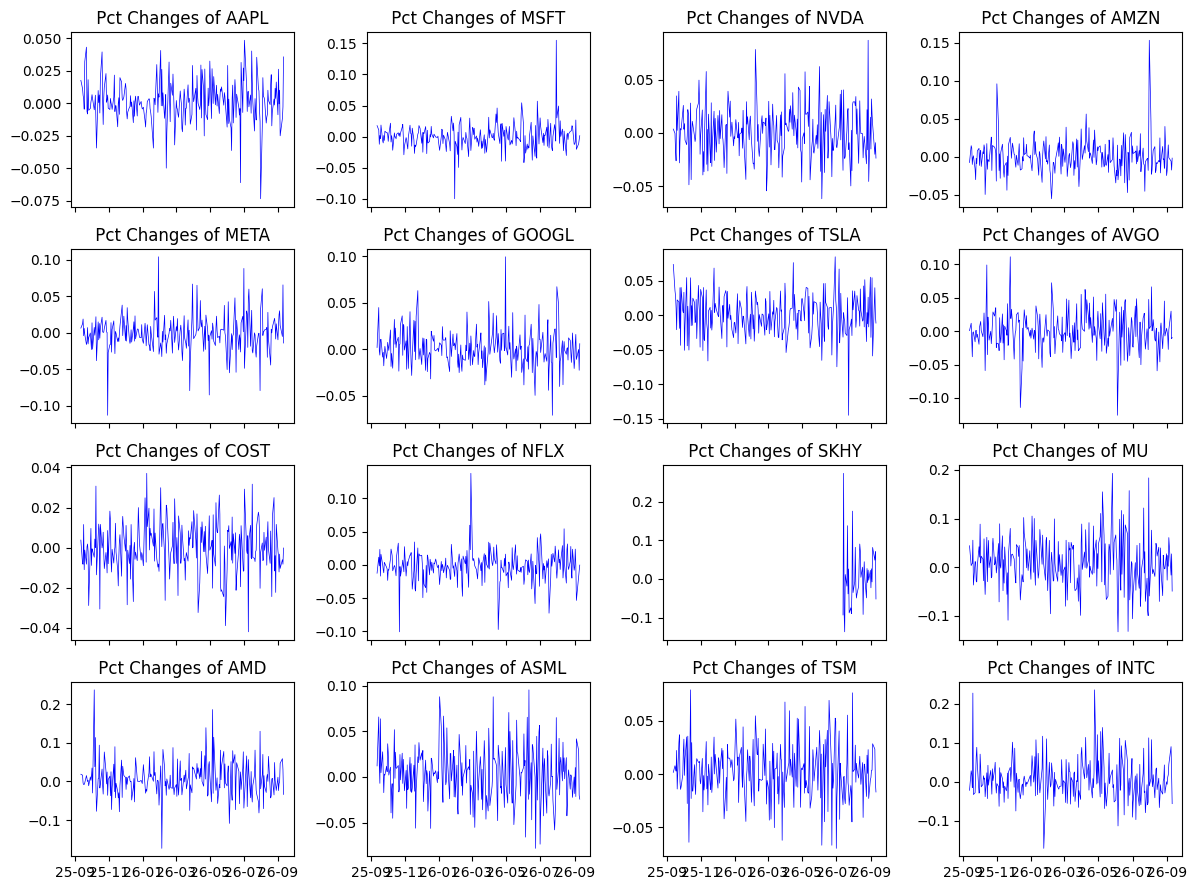

In [10]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

n_plot = len(tickers)

#print(n_plot
fig, axes = plt.subplots(4, 4, figsize=(12, 9), sharex=True)

for ax, ticker in zip(axes.flat, tickers) :
  ax.plot(yymmdd, df_dat_cls[ticker].pct_change(), color='blue', linewidth=0.5)
  ax.set_title(f" Pct Changes of {ticker} ")
#  ax.set_title(f" Closing Prices of {ticker} ")
  ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
plt.tight_layout()
plt.show()

### prices, volumes
level, differences, percentage changes

In [11]:
# NYSE daily stock prices and trading volumes
# 변수로 받는 방법.
yymmdd = df_dat.index   # 자료를 불러올 때, 자동으로 기준 인덱스로 설정된다고 함.
yymmdd = pd.to_datetime( yymmdd )

stck_prc_1= df_dat_cls['NFLX']
stck_prc_2 = df_dat_cls['GOOGL']
#stck_prc_pct = stck_prc.pct_change()



### time series plots
daily prices

### daily pct changes in prices

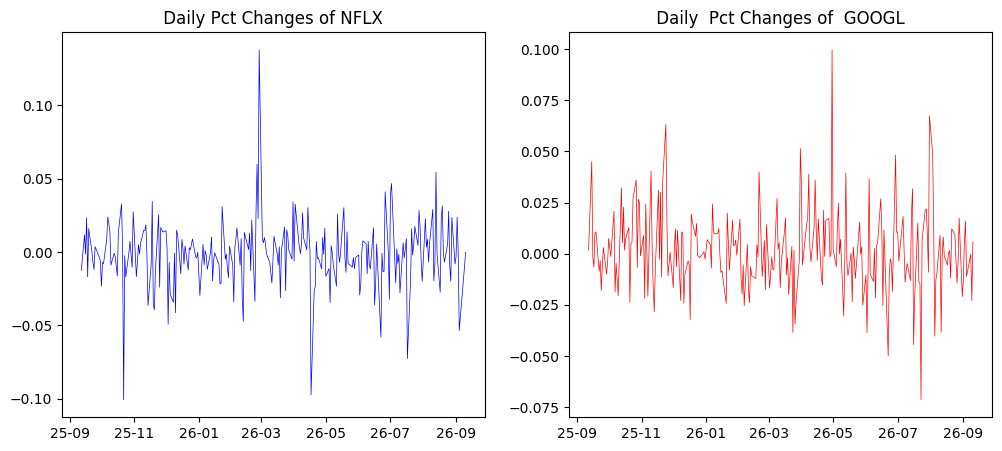

In [12]:

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharex=True)
#axes[0].plot(yymmdd, stck_prc, color='blue', linewidth=0.5)
axes[0].plot(yymmdd, stck_prc_1.pct_change(), color='blue', linewidth=0.5)
#axes[1].plot(yymmdd, stck_vlm, color='red', linewidth=0.5)
axes[1].plot(yymmdd, stck_prc_2.pct_change(), color='red', linewidth=0.5)

# axes[0].set_title(f" Closing Prices of {ticker} ")
axes[0].set_title(f" Daily Pct Changes of NFLX ")
axes[1].set_title(f" Daily  Pct Changes of  GOOGL ")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
#axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))


### distibution of daily price changes

(array([ 0.25739548,  0.77218645,  2.57395485, 13.89935619, 24.19517558,
        15.18633361,  4.63311873,  2.05916388,  0.51479097,  0.        ,
         0.25739548]),
 array([-0.07132621, -0.05578592, -0.04024563, -0.02470534, -0.00916506,
         0.00637523,  0.02191552,  0.03745581,  0.0529961 ,  0.06853639,
         0.08407667,  0.09961696]),
 <BarContainer object of 11 artists>)

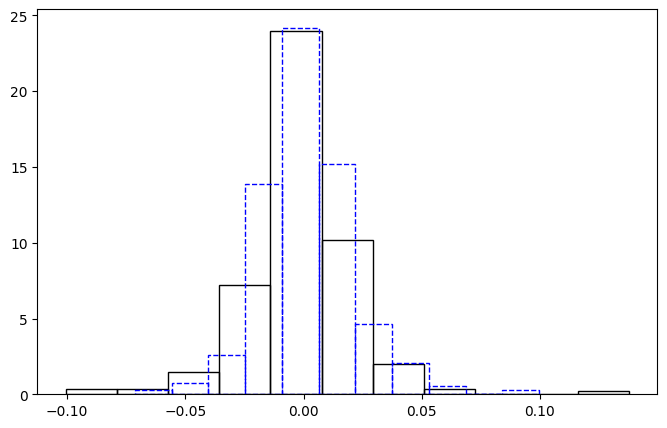

In [13]:

plt.figure(figsize=(8, 5))
plt.hist(stck_prc_1.pct_change(), color='blue', linewidth=1, bins = 11, facecolor='None', edgecolor='black', density=True)
plt.hist(stck_prc_2.pct_change(), color='blue', linewidth=1, bins = 11, facecolor='None', edgecolor='blue', density=True, linestyle='--')
#plt.title(f" distribution of daily percentage change of {ticker} ") # 티커가 아니라서.
